
# Random Forest Project 

For this project we will be exploring publicly available data from [LendingClub.com](www.lendingclub.com). Lending Club connects people who need money (borrowers) with people who have money (investors). Hopefully, as an investor you would want to invest in people who showed a profile of having a high probability of paying you back. We will try to create a model that will help predict this.

Lending club had a [very interesting year in 2016](https://en.wikipedia.org/wiki/Lending_Club#2016), so let's check out some of their data and keep the context in mind. This data is from before they even went public.

We will use lending data from 2007-2010 and be trying to classify and predict whether or not the borrower paid back their loan in full. You can download the data from [here](https://www.lendingclub.com/info/download-data.action) or just use the csv already provided. It's recommended you use the csv provided as it has been cleaned of NA values.

Here are what the columns represent:
* credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
* purpose: The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
* int.rate: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
* installment: The monthly installments owed by the borrower if the loan is funded.
* log.annual.inc: The natural log of the self-reported annual income of the borrower.
* dti: The debt-to-income ratio of the borrower (amount of debt divided by annual income).
* fico: The FICO credit score of the borrower.
* days.with.cr.line: The number of days the borrower has had a credit line.
* revol.bal: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
* revol.util: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
* inq.last.6mths: The borrower's number of inquiries by creditors in the last 6 months.
* delinq.2yrs: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
* pub.rec: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

# Import Libraries

**Import the usual libraries for pandas and plotting. You can import sklearn later on.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Get the Data

** Use pandas to read loan_data.csv as a dataframe called loans.**

In [3]:
import os
os.listdir()

['03-Decision Trees and Random Forest Project - Solutions.ipynb',
 'Decision Trees and Random Forest Project.ipynb',
 '01-Decision Trees and Random Forests in Python.ipynb',
 'Basics Decision Tree & Random Forest.ipynb',
 '.ipynb_checkpoints',
 'loan_data.csv',
 'kyphosis.csv']

In [5]:
df = pd.read_csv('loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


** Check out the info(), head(), and describe() methods on loans.**

In [7]:
df.isna().any() ##no null

credit.policy        False
purpose              False
int.rate             False
installment          False
log.annual.inc       False
dti                  False
fico                 False
days.with.cr.line    False
revol.bal            False
revol.util           False
inq.last.6mths       False
delinq.2yrs          False
pub.rec              False
not.fully.paid       False
dtype: bool

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [21]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
credit.policy        9578 non-null int64
purpose              9578 non-null object
int.rate             9578 non-null float64
installment          9578 non-null float64
log.annual.inc       9578 non-null float64
dti                  9578 non-null float64
fico                 9578 non-null int64
days.with.cr.line    9578 non-null float64
revol.bal            9578 non-null int64
revol.util           9578 non-null float64
inq.last.6mths       9578 non-null int64
delinq.2yrs          9578 non-null int64
pub.rec              9578 non-null int64
not.fully.paid       9578 non-null int64
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


# Exploratory Data Analysis

Let's do some data visualization! We'll use seaborn and pandas built-in plotting capabilities, but feel free to use whatever library you want. Don't worry about the colors matching, just worry about getting the main idea of the plot.

** Create a histogram of two FICO distributions on top of each other, one for each credit.policy outcome.**

*Note: This is pretty tricky, feel free to reference the solutions. You'll probably need one line of code for each histogram, I also recommend just using pandas built in .hist()*

<Axes: xlabel='fico', ylabel='Count'>

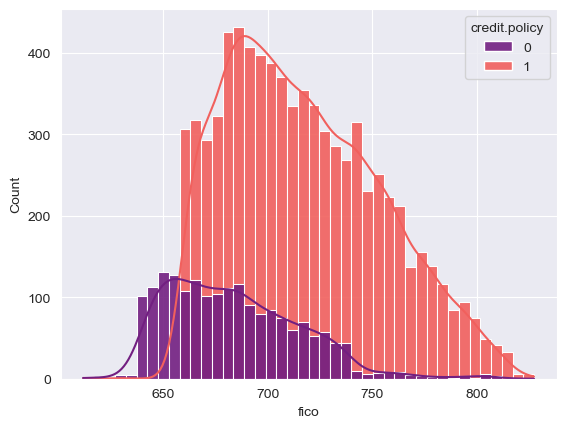

In [38]:
sns.set_style('darkgrid')
sns.histplot(data = df, x = 'fico',hue = 'credit.policy', palette= "magma", alpha = .9) 
##Credit Policy has different distribution, who met the policy have better fico score

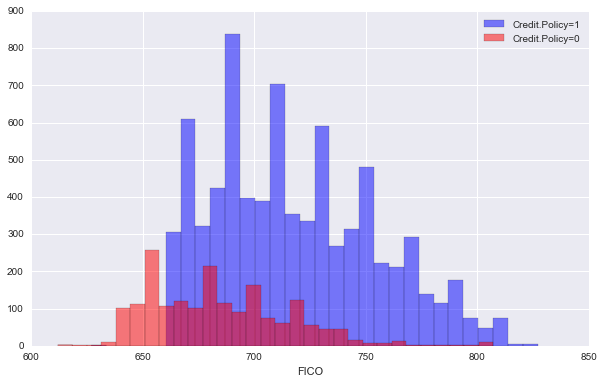

** Create a similar figure, except this time select by the not.fully.paid column.**

<Axes: xlabel='fico', ylabel='Count'>

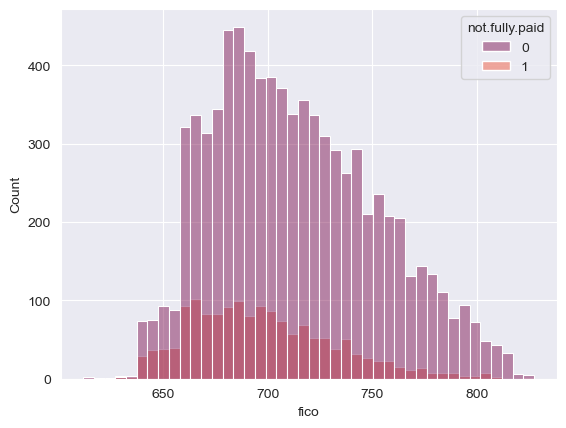

In [67]:
plt.clf()
sns.histplot(data = df, x = 'fico',hue = 'not.fully.paid', palette= "rocket") 
##fico distribution roughly same for group of people who paid loan & who didn't
##Although peak of who didn't fully paid less than who paid

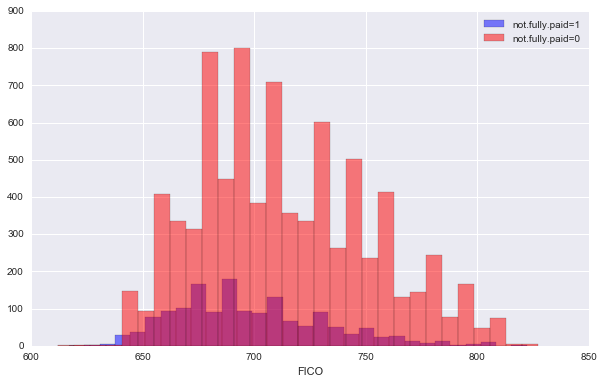

** Create a countplot using seaborn showing the counts of loans by purpose, with the color hue defined by not.fully.paid. **

<Axes: xlabel='purpose', ylabel='count'>

<Figure size 640x480 with 0 Axes>

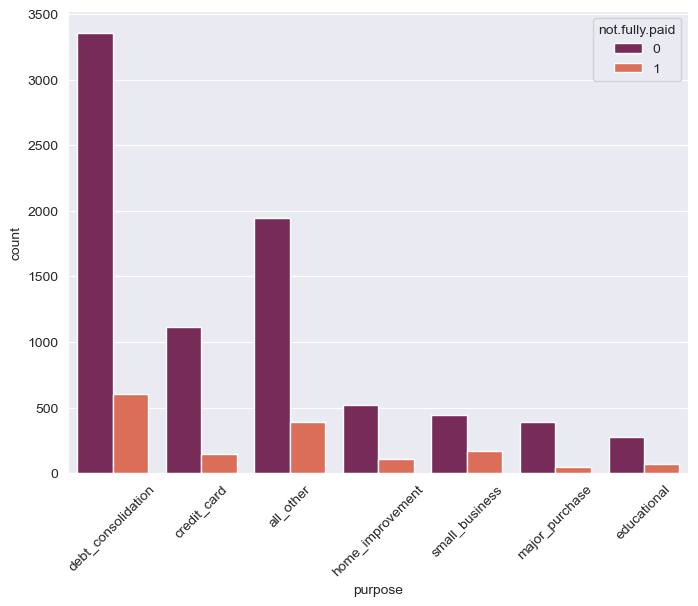

In [88]:
plt.clf()
plt.figure(figsize= (8,6))
plt.xticks(rotation=45)
sns.countplot(data = df, x = 'purpose',hue = 'not.fully.paid', palette= "rocket" ) 
##Mostly people took load for debt consolidation

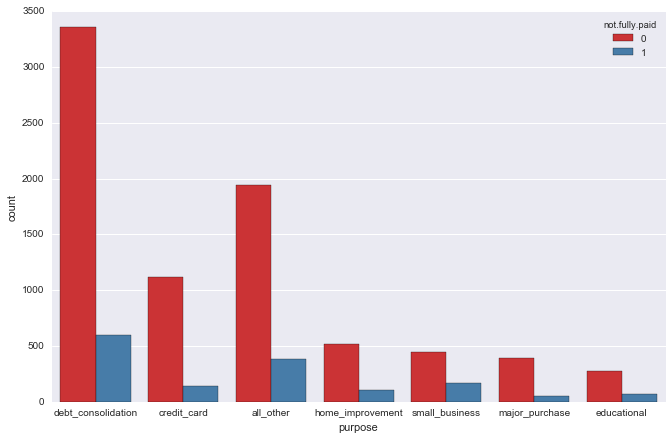

** Let's see the trend between FICO score and interest rate. Recreate the following jointplot.**

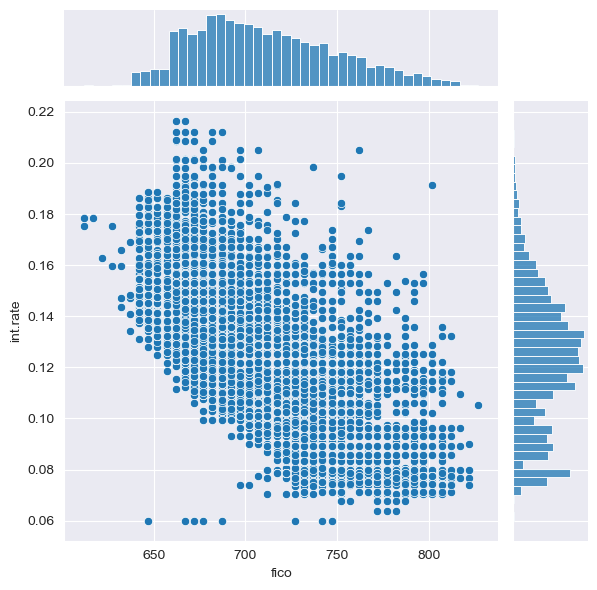

In [95]:
sns.jointplot(data = df, x = 'fico', y = 'int.rate', palette= "flare" ) 
## it is strong -ve relation, 
##higher fico lower interest rate

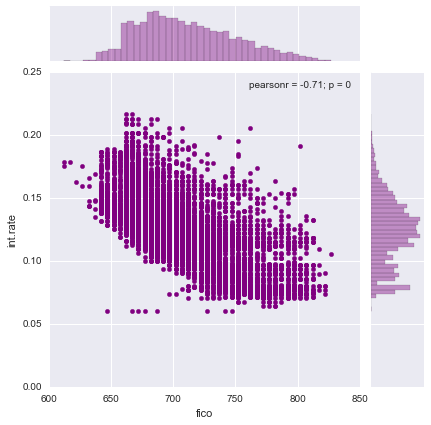

** Create the following lmplots to see if the trend differed between not.fully.paid and credit.policy. Check the documentation for lmplot() if you can't figure out how to separate it into columns.**

<Figure size 640x480 with 0 Axes>

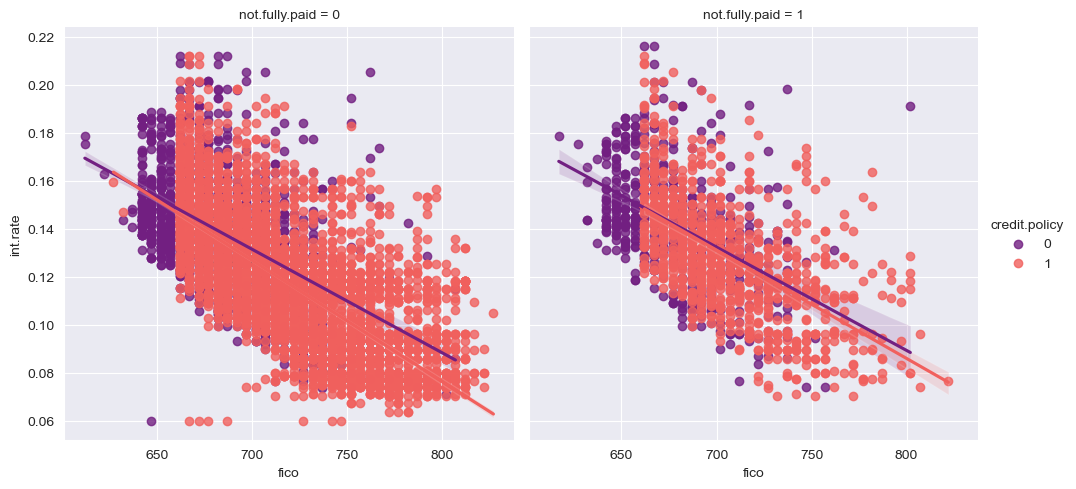

In [156]:
plt.clf()
sns.lmplot(x='fico', y='int.rate', col='not.fully.paid',hue = 'credit.policy' , data=df, palette = 'magma')

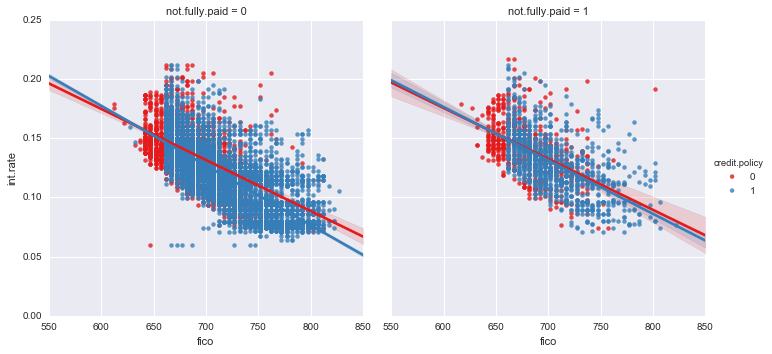

In [276]:
##Correlation

from scipy.stats import pointbiserialr

for i in df.columns[~df.columns.isin(['purpose','not.fully.paid'])]:
    r, p = pointbiserialr(df['not.fully.paid'], df[i])

    if r<.1 and p >.05:
        print(f"{i} has {r:.4f} & {p:.8f}. It should be drop XX")
    elif  p > .05:
        print(f"{i} has {r:.4f} & {p:.8f}. Check there is correlation but with noise")
    else:
        print(f"{i} has {r:.4f} & {p:.8f}. Keep the variable") ##delinq.2yrs correlation is wek & also seems insig

credit.policy has -0.1581 & 0.00000000. Keep the variable
int.rate has 0.1596 & 0.00000000. Keep the variable
installment has 0.0500 & 0.00000100. Keep the variable
log.annual.inc has -0.0334 & 0.00106372. Keep the variable
dti has 0.0374 & 0.00025492. Keep the variable
fico has -0.1497 & 0.00000000. Keep the variable
days.with.cr.line has -0.0292 & 0.00421574. Keep the variable
revol.bal has 0.0537 & 0.00000015. Keep the variable
revol.util has 0.0821 & 0.00000000. Keep the variable
inq.last.6mths has 0.1495 & 0.00000000. Keep the variable
delinq.2yrs has 0.0089 & 0.38481059. It should be drop XX
pub.rec has 0.0486 & 0.00000192. Keep the variable


# Setting up the Data

Let's get ready to set up our data for our Random Forest Classification Model!

**Check loans.info() again.**

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_trans = Pipeline([('cat', OneHotEncoder(drop='first'))])
numeric_trans = Pipeline([('scaling',StandardScaler())])
# df.loc[:,df.columns.isin(df.dtypes[df.dtypes == 'int'].index] #.value_counts
# df.loc[:, df.columns.isin(df.dtypes[df.dtypes == 'int'].index)].value_counts()

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [11]:
cat_col = df.dtypes[df.dtypes == 'object'].index.tolist()
non_cat_col = df.dtypes[~(df.dtypes == 'object')].index.tolist()
non_cat_col.pop()
# len(non_cat_col)

'not.fully.paid'

In [13]:
non_cat_col

['credit.policy',
 'int.rate',
 'installment',
 'log.annual.inc',
 'dti',
 'fico',
 'days.with.cr.line',
 'revol.bal',
 'revol.util',
 'inq.last.6mths',
 'delinq.2yrs',
 'pub.rec']

In [15]:
cat_col

['purpose']

## Data Pre-Processing

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

In [19]:
pre_pipe = ColumnTransformer([ ('cat',cat_trans,cat_col), ('non_cat',numeric_trans,non_cat_col)])

In [251]:
# pipe_f = Pipeline([('transf', pre_pipe),('LR', LogisticRegression())])

In [21]:
(df['not.fully.paid'].value_counts()[1]/df['not.fully.paid'].value_counts()[0])*100
##Case of Mild Imbalanced

19.05531385954009

## Train Test Split

Now its time to split our data into a training set and a testing set!

** Use sklearn to split your data into a training set and a testing set as we've done in the past.**

In [23]:
X = df.loc[:,~df.columns.isin(['not.fully.paid'])]
Y = df.loc[:,df.columns.isin(['not.fully.paid'])]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

## Training a Logistic Regression

In [699]:
para_LR = {
    'penalty' :[ 'L1','L2','elasticnet',None ], #[ 'elasticnet', None],
    'l1_ratio': [0,1,10,0.2,0.5,0.7, 1],
    'class_weight': [ {0:1,1:4}, {0:1,1:6},'balanced',None], 
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'C': [1,.2,.01,.001,.1,10,100,1000,50,7],
    'random_state': [101]

}    

In [713]:
para_LR = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'l1_ratio': [0, 0.2, 0.5, 0.7, 1],  # Only for elasticnet
    'class_weight': [None, 'balanced', {0:1, 1:4}, {0:1, 1:6}],
    'solver': ['liblinear', 'saga'],  # Only these support l1 and elasticnet
    'C': [0.01, 0.1, 1, 10, 100],
    'random_state': [101]
}


In [715]:
pipe_f = Pipeline([('transf', pre_pipe),('LR', GridSearchCV(LogisticRegression(max_iter = 1000),param_grid= para_LR,scoring= "f1",n_jobs=-1, cv = 5, verbose= 2 ) )])
# model_lr = GridSearchCV(pipe_f,param_grid= para_LR,scoring= "f1",n_jobs=-1, cv = 3, verbose= 2)

# Coefficients Value to determine Importance

In [768]:
pipe_f.named_steps['LR'].best_estimator_.coef_[0].tolist()

[-0.17439940783439162,
 -0.14319116549133354,
 0.0,
 0.0043900262399725895,
 -0.00014187222445065652,
 0.19912123433445106,
 -0.1267587765686078,
 0.1301367393654437,
 0.17776038958226761,
 -0.18824030279327317,
 0.0,
 -0.22340470317745623,
 0.003619534201340747,
 0.10706271518544919,
 0.03767672309863021,
 0.21348823011754925,
 -0.05390502449409362,
 0.06184011967173624]

In [756]:
cat_feature_names = pre_pipe.named_transformers_['cat'].get_feature_names_out(cat_col)
num_feature_names = non_cat_col 
all_feature_names = np.concatenate([cat_feature_names, num_feature_names])

In [766]:
# len(all_feature_names), len(pipe_f.named_steps['LR'].best_estimator_.coef_[0].tolist())
cfs = pipe_f.named_steps['LR'].best_estimator_.coef_[0].tolist()
for i in range(0,len(all_feature_names)):
    if cfs[i] == 0:
        print(f" for {all_feature_names[i]} coeff is: {cfs[i]:.2f} ---- Remove It XX")
    else:
        print(f" for {all_feature_names[i]} coeff is: {cfs[i]:.2f}")

 for purpose_credit_card coeff is: -0.17
 for purpose_debt_consolidation coeff is: -0.14
 for purpose_educational coeff is: 0.00 ---- Remove It XX
 for purpose_home_improvement coeff is: 0.00
 for purpose_major_purchase coeff is: -0.00
 for purpose_small_business coeff is: 0.20
 for credit.policy coeff is: -0.13
 for int.rate coeff is: 0.13
 for installment coeff is: 0.18
 for log.annual.inc coeff is: -0.19
 for dti coeff is: 0.00 ---- Remove It XX
 for fico coeff is: -0.22
 for days.with.cr.line coeff is: 0.00
 for revol.bal coeff is: 0.11
 for revol.util coeff is: 0.04
 for inq.last.6mths coeff is: 0.21
 for delinq.2yrs coeff is: -0.05
 for pub.rec coeff is: 0.06


In [719]:
pipe_f.named_steps['LR'].best_score_

0.3431228534306049

In [721]:
pipe_f.named_steps['LR'].best_params_

{'C': 0.01,
 'class_weight': 'balanced',
 'l1_ratio': 0.2,
 'penalty': 'elasticnet',
 'random_state': 101,
 'solver': 'saga'}

In [723]:
y_pred_train = pipe_f.predict(X_train)

print("**** Train  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_train,y_pred_train) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_train,y_pred_train)*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_train,y_pred_train)*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_train,y_pred_train)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_train,y_pred_train)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_train,y_pred_train)*100,1), "%")

**** Train  Data Metrics ****
Accuracy Score 64.991 %
F1 Score 34.9 %
Precision Score 24.8 %
Recall Score 58.9 %
Misclasification %  35.009 %


In [725]:
##Validation score
y_pred_val = pipe_f.predict(X_val)

print("**** Validation  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_val,y_pred_val ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_val,y_pred_val )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_val,y_pred_val )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_val,y_pred_val )*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_val,y_pred_val )) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Validation  Data Metrics ****
Accuracy Score 63.814 %
F1 Score 33.0 %
Precision Score 23.7 %
Recall Score 54.5 %
Misclasification %  36.186 %


In [727]:
##Tesr score
y_pred_test = pipe_f.predict(X_test)

print("**** Test  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_test,y_pred_test ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_test,y_pred_test )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_test,y_pred_test )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_test,y_pred_test)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_test,y_pred_test)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Test  Data Metrics ****
Accuracy Score 65.414 %
F1 Score 37.3 %
Precision Score 26.3 %
Recall Score 64.1 %
Misclasification %  34.586 %


# SMOTE to generate balanced data

In [27]:
from imblearn.over_sampling import SMOTE

X_train_trans = pre_pipe.fit_transform(X_train)

sm = SMOTE(random_state=101)
X_resampled, y_resampled = sm.fit_resample(X_train_trans, y_train)

In [531]:
X_resampled.shape

(11274, 18)

In [535]:
y_resampled.value_counts() ##Balanced class

not.fully.paid
0                 5637
1                 5637
Name: count, dtype: int64

In [681]:
para_LR = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'l1_ratio': [0, 0.2,0.3,0.4, 0.5, 0.7, 1],  
    'class_weight': [None], #, 'balanced', {0:1, 1:4}, {0:1, 1:6}
    'solver': ['liblinear', 'saga'],  # Only these support l1 and elasticnet
    'C': [0.01, 0.1, 2,1,4,5,7, 10, 100],
    'random_state': [101]
}


In [685]:
grid.best_score_

0.6170836178587467

In [687]:
grid.best_params_

{'C': 0.01,
 'class_weight': None,
 'l1_ratio': 0,
 'penalty': None,
 'random_state': 101,
 'solver': 'saga'}

## Predictions and Evaluation of Logistic Regression

In [689]:
y_trans_train = pre_pipe.transform(X_train)
y_pred_train = grid.predict(y_trans_train)

print("**** Train  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_train,y_pred_train) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_train,y_pred_train)*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_train,y_pred_train)*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_train,y_pred_train)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_train,y_pred_train)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_train,y_pred_train)*100,1), "%")

**** Train  Data Metrics ****
Accuracy Score 63.499 %
F1 Score 34.0 %
Precision Score 23.8 %
Recall Score 59.0 %
Misclasification %  36.501 %


In [691]:
X_val_trans = pre_pipe.transform(X_val)
y_val_pred = grid.predict(X_val_trans)

In [693]:
print("**** Validation  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_val,y_val_pred ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_val,y_val_pred )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_val,y_val_pred )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_val,y_val_pred )*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_val,y_val_pred )) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Validation  Data Metrics ****
Accuracy Score 63.605 %
F1 Score 34.7 %
Precision Score 24.6 %
Recall Score 59.1 %
Misclasification %  36.395 %


In [695]:
X_test_trans = pre_pipe.transform(X_test)
y_test_pred = grid.predict(X_test_trans)

In [697]:
##Tesr score
y_pred_test = pipe_f.predict(X_test)

print("**** Test  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_test,y_test_pred ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_test,y_test_pred )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_test,y_test_pred )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_test,y_test_pred)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_test,y_test_pred)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Test  Data Metrics ****
Accuracy Score 64.509 %
F1 Score 37.2 %
Precision Score 26.0 %
Recall Score 65.4 %
Misclasification %  35.491 %


In [777]:
# pipe_f.named_steps['LR'].best_estimator_.coef_[0].tolist()
grid.best_estimator_.coef_[0]

array([-0.71540541, -0.2943443 , -0.05696681,  0.02476134, -0.72422845,
        0.37137361, -0.15306706, -0.0185638 ,  0.28444022, -0.27133377,
       -0.00123622, -0.40115532,  0.02072092,  0.12214719,  0.05234304,
        0.20868203, -0.11349046,  0.08286714])

In [781]:
# len(all_feature_names), len(pipe_f.named_steps['LR'].best_estimator_.coef_[0].tolist())
##this suggest none
cfs_grid = grid.best_estimator_.coef_[0].tolist()
for i in range(0,len(all_feature_names)):
    if cfs_grid[i] == 0:
        print(f" for {all_feature_names[i]} coeff is: {cfs_grid[i]:.2f} ---- Remove It XX")
    else:
        print(f" for {all_feature_names[i]} coeff is: {cfs_grid[i]:.2f}")

 for purpose_credit_card coeff is: -0.72
 for purpose_debt_consolidation coeff is: -0.29
 for purpose_educational coeff is: -0.06
 for purpose_home_improvement coeff is: 0.02
 for purpose_major_purchase coeff is: -0.72
 for purpose_small_business coeff is: 0.37
 for credit.policy coeff is: -0.15
 for int.rate coeff is: -0.02
 for installment coeff is: 0.28
 for log.annual.inc coeff is: -0.27
 for dti coeff is: -0.00
 for fico coeff is: -0.40
 for days.with.cr.line coeff is: 0.02
 for revol.bal coeff is: 0.12
 for revol.util coeff is: 0.05
 for inq.last.6mths coeff is: 0.21
 for delinq.2yrs coeff is: -0.11
 for pub.rec coeff is: 0.08


## Training a Decision Tree Model

In [29]:
from sklearn.tree import DecisionTreeClassifier

**Create an instance of DecisionTreeClassifier() called dtree and fit it to the training data.**

In [31]:
cat_only_tranf = ColumnTransformer([
    ('cat', OneHotEncoder(), cat_col)
], remainder='passthrough')

In [63]:
pipe_dt = DecisionTreeClassifier()
pipe_dt.fit(cat_only_tranf.fit_transform(X_train),y_train)

DecisionTreeClassifier()

In [81]:
pipe_dt.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [97]:
pipe_dt.get_depth()
pipe_dt.get_n_leaves()
pipe_dt.criterion

'gini'

In [99]:
param_dt = {'criterion': ['gini', 'entropy', 'log_loss'], #['gini', 'entropy', 'log_loss']
           'random_state': [101],
           'min_impurity_decrease': [.002,.001,0,.1,1,.01,5],
           'class_weight': ['balanced',{0:1,1:4}, {0:1,1:6},{0:1,1:9},None, ], 
            'max_depth': [5,8,25,50,10,], 
            'min_samples_split': [5,8,10,15],
            'min_samples_leaf' : [5,8,15,10] #removed 5 from min, max params
           
           }
           

In [101]:
import datetime
import time

In [104]:
print(f"Total time taken: {(end_time - start_time):.2f} seconds")

Total time taken: 165.74 seconds


In [105]:
print(f"Total time taken: {(end_time - start_time)/60:.2f} mins")

Total time taken: 2.76 mins


In [109]:
pipe_dt.named_steps['DT'].best_params_

{'class_weight': {0: 1, 1: 4},
 'criterion': 'gini',
 'max_depth': 5,
 'min_impurity_decrease': 0.002,
 'min_samples_leaf': 5,
 'min_samples_split': 5,
 'random_state': 101}

In [111]:
pipe_dt.named_steps['DT'].best_score_

0.3348831036846964

## Predictions and Evaluation of Decision Tree

In [115]:
y_pred_train_dt = pipe_dt.predict(X_train)
#pipe_dt.fit(cat_only_tranf.fit_transform(X_train),y_train)
# y_pred_train_dt = pipe_dt.predict(cat_only_tranf.transform(X_train))

print("**** Train  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_train,y_pred_train_dt) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_train,y_pred_train_dt)*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_train,y_pred_train_dt)*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_train,y_pred_train_dt)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_train,y_pred_train_dt)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_train,y_pred_train)*100,1), "%")

**** Train  Data Metrics ****
Accuracy Score 70.122 %
F1 Score 34.7 %
Precision Score 26.6 %
Recall Score 49.9 %
Misclasification %  29.878 %


In [117]:
##Validation score
y_pred_val_dt = pipe_dt.predict(X_val)
# y_pred_val_dt = pipe_dt.predict(cat_only_tranf.transform(X_val))

print("**** Validation  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_val,y_pred_val_dt ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_val,y_pred_val_dt )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_val,y_pred_val_dt )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_val,y_pred_val_dt )*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_val,y_pred_val_dt )) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Validation  Data Metrics ****
Accuracy Score 69.589 %
F1 Score 32.5 %
Precision Score 25.5 %
Recall Score 44.7 %
Misclasification %  30.411 %


In [119]:
##Test score
y_pred_test_dt = pipe_dt.predict(X_test)
# y_pred_test_dt = pipe_dt.predict(cat_only_tranf.transform(X_test))

print("**** Test  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_test,y_pred_test_dt ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_test,y_pred_test_dt )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_test,y_pred_test_dt )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_test,y_pred_test_dt)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_test,y_pred_test_dt)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Test  Data Metrics ****
Accuracy Score 69.45 %
F1 Score 35.2 %
Precision Score 26.7 %
Recall Score 51.5 %
Misclasification %  30.55 %


In [121]:
print(metrics.confusion_matrix(y_test,y_pred_test_dt ))

[[879 327]
 [112 119]]


In [123]:
print(metrics.classification_report(y_test,y_pred_test_dt ))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1206
           1       0.27      0.52      0.35       231

    accuracy                           0.69      1437
   macro avg       0.58      0.62      0.58      1437
weighted avg       0.79      0.69      0.73      1437



             precision    recall  f1-score   support

          0       0.85      0.81      0.83      2431
          1       0.16      0.20      0.18       443

avg / total       0.74      0.72      0.73      2874



[[1980  451]
 [ 355   88]]


## SMOTE With Decision Tree

In [168]:
param_dt1 = {'criterion': ['gini', 'entropy', 'log_loss'], #['gini', 'entropy', 'log_loss']
           'random_state': [101],
           'min_impurity_decrease': [.002,.001,0,.1,1,.01,5],
           'class_weight': [None,{0:1,1:4}, {0:1,1:6},{0:1,1:9}, ], 
            'max_depth': [5,8,25,50,10], 
            'min_samples_split': [5,8,10,15],
            'min_samples_leaf' : [5,8,15,10] #removed 5 from min, max params
           
           }
           

In [137]:
X_train_trans1 = cat_only_tranf.fit_transform(X_train)

sm = SMOTE(random_state=101)
X_resampled1, y_resampled1 = sm.fit_resample(X_train_trans1, y_train)

In [170]:
start_time = time.time()
grid_dr = GridSearchCV(DecisionTreeClassifier(), param_grid=param_dt1,
                    scoring="f1", cv=5, verbose=2, n_jobs=-1)
grid_dr.fit(X_resampled1, y_resampled1)
end_time = time.time()

Fitting 5 folds for each of 6720 candidates, totalling 33600 fits

[CV] END class_weight={0: 1, 1: 9}, criterion=log_loss, max_depth=5, min_impurity_decrease=0.001, min_samples_leaf=5, min_samples_split=5, random_state=101; total time=   0.1s
[CV] END class_weight={0: 1, 1: 9}, criterion=log_loss, max_depth=5, min_impurity_decrease=0.001, min_samples_leaf=5, min_samples_split=5, random_state=101; total time=   0.1s
[CV] END class_weight={0: 1, 1: 9}, criterion=log_loss, max_depth=5, min_impurity_decrease=0.001, min_samples_leaf=5, min_samples_split=5, random_state=101; total time=   0.1s
[CV] END class_weight={0: 1, 1: 9}, criterion=log_loss, max_depth=5, min_impurity_decrease=0.001, min_samples_leaf=5, min_samples_split=5, random_state=101; total time=   0.1s
[CV] END class_weight={0: 1, 1: 9}, criterion=log_loss, max_depth=5, min_impurity_decrease=0.001, min_samples_leaf=5, min_samples_split=5, random_state=101; total time=   0.1s
[CV] END class_weight={0: 1, 1: 9}, criterion=log_los

In [171]:
print(f"Total time taken: {(end_time - start_time):.2f} seconds")

Total time taken: 239.56 seconds


In [172]:
print(f"Total time taken: {(end_time - start_time)/60:.2f} mins")

Total time taken: 3.99 mins


In [176]:
grid_dr.best_params_

{'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'min_impurity_decrease': 0.001,
 'min_samples_leaf': 15,
 'min_samples_split': 5,
 'random_state': 101}

In [178]:
grid_dr.best_score_

0.7768818642675359

## Prediction SMOTE Decision Tree

In [180]:
y_pred_train_dt_sm = grid_dr.predict(cat_only_tranf.transform(X_train))
#pipe_dt.fit(cat_only_tranf.fit_transform(X_train),y_train)
# y_pred_train_dt = pipe_dt.predict(cat_only_tranf.transform(X_train))

print("**** Train  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_train,y_pred_train_dt_sm) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_train,y_pred_train_dt_sm)*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_train,y_pred_train_dt_sm)*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_train,y_pred_train_dt_sm)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_train,y_pred_train_dt_sm)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_train,y_pred_train)*100,1), "%")

**** Train  Data Metrics ****
Accuracy Score 83.741 %
F1 Score 14.7 %
Precision Score 44.5 %
Recall Score 8.8 %
Misclasification %  16.259 %


In [182]:
##Validation score
y_pred_val_dt_sm = grid_dr.predict(cat_only_tranf.transform(X_val))
# y_pred_val_dt = pipe_dt.predict(cat_only_tranf.transform(X_val))

print("**** Validation  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_val, y_pred_val_dt_sm ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_val,y_pred_val_dt_sm )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_val,y_pred_val_dt_sm )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_val,y_pred_val_dt_sm )*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_val,y_pred_val_dt_sm )) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Validation  Data Metrics ****
Accuracy Score 83.09 %
F1 Score 10.3 %
Precision Score 38.9 %
Recall Score 6.0 %
Misclasification %  16.91 %


In [184]:
##Test score
y_pred_test_dt_sm = grid_dr.predict(cat_only_tranf.transform(X_test))
# y_pred_test_dt = pipe_dt.predict(cat_only_tranf.transform(X_test))

print("**** Test  Data Metrics ****")
print("Accuracy Score", round(metrics.accuracy_score(y_test,y_pred_test_dt_sm ) *100,3), "%")
print("F1 Score", round(metrics.f1_score(y_test,y_pred_test_dt_sm )*100,1), "%")
print("Precision Score",round(metrics.precision_score(y_test,y_pred_test_dt_sm )*100,1), "%")
print("Recall Score",round(metrics.recall_score(y_test,y_pred_test_dt_sm)*100,1), "%")
print("Misclasification % ", round((1-metrics.accuracy_score(y_test,y_pred_test_dt_sm)) *100.00,3), "%")
# print("ROC-AUC Score",round(metrics.roc_auc_score(y_val,y_pred_val)*100,1), "%")

**** Test  Data Metrics ****
Accuracy Score 82.811 %
F1 Score 10.8 %
Precision Score 32.6 %
Recall Score 6.5 %
Misclasification %  17.189 %


In [ ]:
##not working as f1 is too low

## Training the Random Forest model

Now its time to train our model!

**Create an instance of the RandomForestClassifier class and fit it to our training data from the previous step.**

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=600, n_jobs=1,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

## Predictions and Evaluation

Let's predict off the y_test values and evaluate our model.

** Predict the class of not.fully.paid for the X_test data.**

**Now create a classification report from the results. Do you get anything strange or some sort of warning?**

             precision    recall  f1-score   support

          0       0.85      1.00      0.92      2431
          1       0.56      0.01      0.02       443

avg / total       0.80      0.85      0.78      2874



**Show the Confusion Matrix for the predictions.**

[[2427    4]
 [ 438    5]]


**What performed better the random forest or the decision tree?**

# Great Job!